### Model Training Analysis

In [7]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set constants
REPO_ROOT = Path(os.getcwd()).resolve().parent
FIG_DIR = REPO_ROOT / "results" / "figures"# Load training data

In [19]:
# Load training data
results_df = pd.read_csv(REPO_ROOT / "results" / "metrics" / "brms_grid_search_v1.csv")

In [20]:
# Map the model names to human readable names
map = {
    "brms_beta0.5_int3.5_negbinomial_iter1000": "Beta(0.5, 3.5) NB",
    "brms_beta1.0_int3.0_negbinomial_iter1000": "Beta(1.0, 3.0) NB",
    "brms_beta1.0_int3.5_negbinomial_iter1000": "Beta(1.0, 3.5) NB",
    "brms_beta1.0_int3.5_poisson_iter1000": "Beta(1.0, 3.5) POIS",
}

results_df["model_name_hf"] = results_df["model_name"].map(map)

In [21]:
results_df.head()

,model_name,training_version,prior_beta_sd,prior_int_mean,family,iter,warmup,train_time_min,mae,rmse,mape,coverage,waic,loo_ic,model_name_hf
0,brms_beta1.0_int3.0_negbinomial_iter1000,v1,1.0,3.0,negbinomial,1000,500,NaN,10.57,15.52,34.65,94.81,246339.08,246339.41,"Beta(1.0, 3.0) NB"
1,brms_beta1.0_int3.5_negbinomial_iter1000,v1,1.0,3.5,negbinomial,1000,500,NaN,10.58,15.55,34.68,94.86,246340.48,246340.78,"Beta(1.0, 3.5) NB"
2,brms_beta0.5_int3.5_negbinomial_iter1000,v1,0.5,3.5,negbinomial,1000,500,NaN,10.58,15.55,34.67,94.87,246341.21,246341.42,"Beta(0.5, 3.5) NB"
3,brms_beta1.0_int3.5_poisson_iter1000,v1,1.0,3.5,poisson,1000,500,NaN,10.61,15.61,34.74,70.12,329063.27,329064.58,"Beta(1.0, 3.5) POIS"


/var/folders/v9/sbw6dcrd0y1_4_5_6zn5lw6h0000gn/T/ipykernel_758/1072199267.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


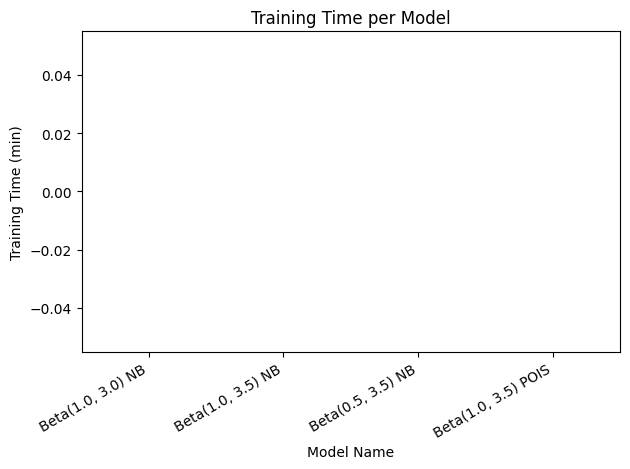

In [23]:
# Training time per model
ax = sns.barplot(
    data=results_df,
    x="model_name_hf",
    y="train_time_min",
    palette="viridis"
)
ax.set_ylabel("Training Time (min)")
ax.set_xlabel("Model Name")
ax.set_title("Training Time per Model")
plt.xticks(rotation=30, ha='right')

# Show exact value on top of each bar
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", 
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# Save plot
plt.savefig(FIG_DIR / "training_time_per_model.png", dpi=300)

plt.show()

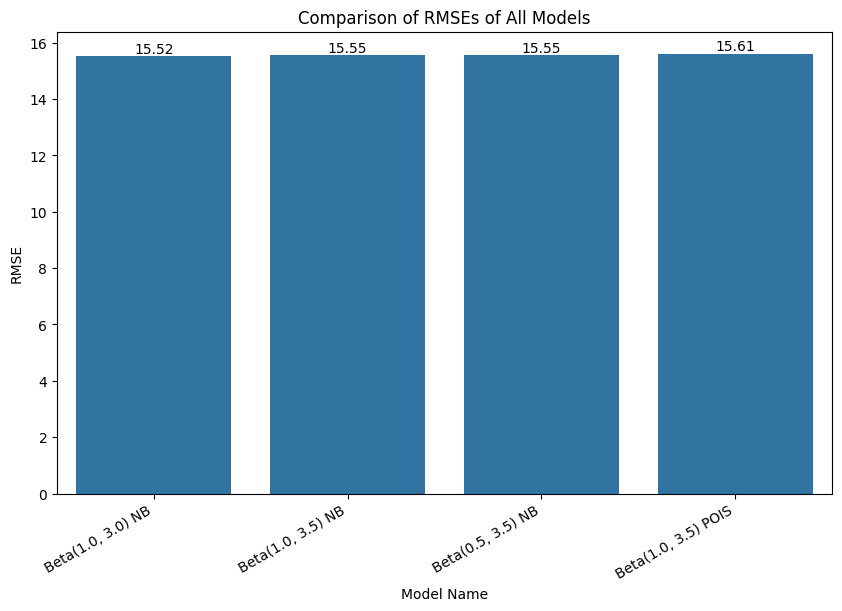

In [24]:
# RMSE over all models
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="model_name_hf", y="rmse", data=results_df)
plt.xticks(rotation=30, ha='right')
plt.xlabel("Model Name")
plt.ylabel("RMSE")
plt.title("Comparison of RMSEs of All Models")

# Add exact values above each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", 
                (bar.get_x() + bar.get_width() / 2, height), 
                ha='center', va='bottom', fontsize=10)

# Save plot
plt.savefig(FIG_DIR / "rmse_over_all_models.png", dpi=300)

plt.show()

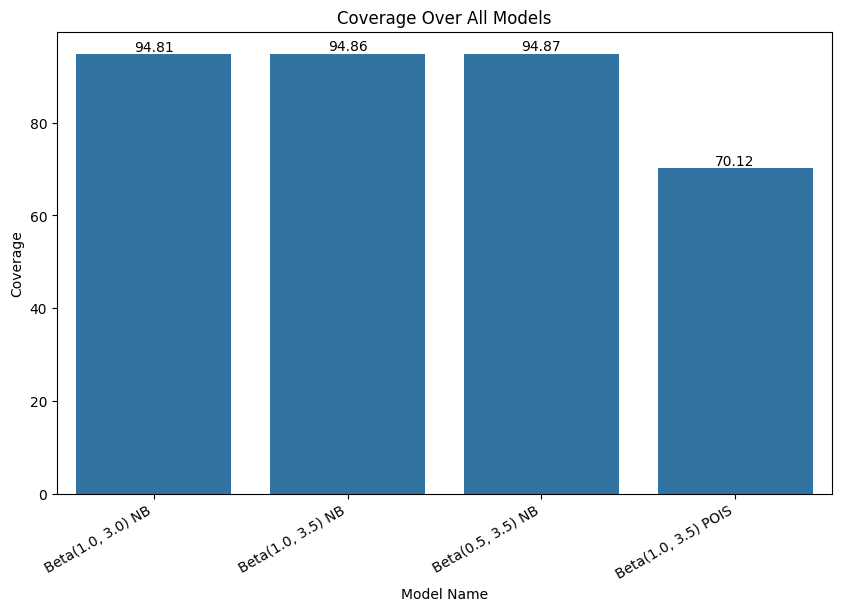

In [25]:
# Coverage over all models
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="model_name_hf", y="coverage", data=results_df)
plt.xticks(rotation=30, ha='right')
plt.xlabel("Model Name")
plt.ylabel("Coverage")
plt.title("Coverage Over All Models")

# Add exact values above each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", 
                (bar.get_x() + bar.get_width() / 2, height), 
                ha='center', va='bottom', fontsize=10)

# Save plot
plt.savefig(FIG_DIR / "coverage_over_all_models.png", dpi=300)

plt.show()


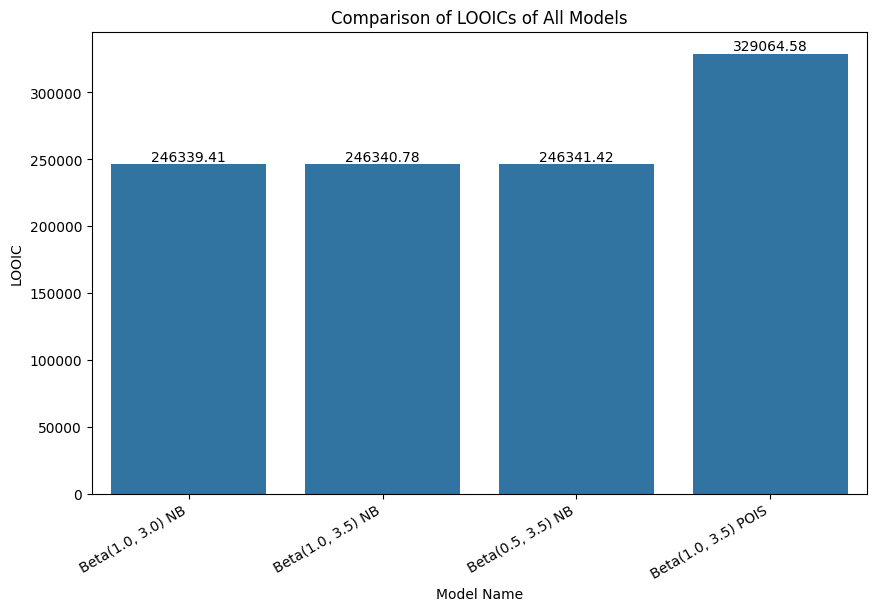

In [26]:
# LOO information criterion for all models
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="model_name_hf", y="loo_ic", data=results_df)
plt.xticks(rotation=30, ha='right')
plt.xlabel("Model Name")
plt.ylabel("LOOIC")
plt.title("Comparison of LOOICs of All Models")

# Add exact values above each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", 
                (bar.get_x() + bar.get_width() / 2, height), 
                ha='center', va='bottom', fontsize=10)

# Save plot
plt.savefig(FIG_DIR / "looic_over_all_models.png", dpi=300)

plt.show()


**Analysis**
1. All of the Negative Binomial models performed similarly, with the Poission baseline BRMS model performing significantly worse across all performance metrics (except for RMSE)
2. When comparing between the Bayesian Negative Bernoulli models using the LOO IC, all of the models performed +/- 1, which is expected with a large amount of data that we used (~37K records)
3. Coverage wise, all of the models performed very similar to eachother.

This likely means that we need to add more features to the model to help account for things that may not already be in the data.

### Model Training Analysis - V2

In [29]:
df_v2 = pd.read_csv(REPO_ROOT / "results" / "metrics" / "brms_grid_search_v2.csv")

In [31]:
# Map to human readable names
map_v2 = {
    "brms_beta0.5_int3.5_negbinomial_iter1000_v2": "Beta(0.5, 3.5) NB",
    "brms_beta1.0_int3.0_negbinomial_iter1000_v2": "Beta(1.0, 3.0) NB",
    "brms_beta1.0_int3.5_negbinomial_iter1000_v2": "Beta(1.0, 3.5) NB",
    "brms_beta1.0_int3.5_poisson_iter1000_v2": "Beta(1.0, 3.5) POIS",
}

df_v2["model_name_hf"] = df_v2["model_name"].map(map_v2)

df_v2.head()


,model_name,prior_beta_sd,prior_int_mean,family,iter,warmup,train_time_min,mae,rmse,mape,coverage,waic,loo_ic,model_name_hf
0,brms_beta1.0_int3.5_negbinomial_iter1000_v2,1.0,3.5,negbinomial,1000,500,14.80,1.122000e+01,1.666000e+01,3.750000e+01,95.48,2.485247e+05,2.485249e+05,"Beta(1.0, 3.5) NB"
1,brms_beta1.0_int3.0_negbinomial_iter1000_v2,1.0,3.0,negbinomial,1000,500,15.80,1.124000e+01,1.667000e+01,3.754000e+01,95.35,2.485242e+05,2.485244e+05,"Beta(1.0, 3.0) NB"
2,brms_beta0.5_int3.5_negbinomial_iter1000_v2,0.5,3.5,negbinomial,1000,500,12.00,1.124000e+01,1.668000e+01,3.757000e+01,95.39,2.485254e+05,2.485255e+05,"Beta(0.5, 3.5) NB"
3,brms_beta1.0_int3.5_poisson_iter1000_v2,1.0,3.5,poisson,1000,500,14.74,8.729896e+64,6.885522e+66,6.664044e+64,67.38,9.755866e+264,9.945570e+132,"Beta(1.0, 3.5) POIS"


In [36]:
# Create a table to compare the performance of the models
model_names = df_v2["model_name_hf"].values
v1_mae = results_df["mae"].values
v2_mae = df_v2["mae"].values
v1_rmse = results_df["rmse"].values
v2_rmse = df_v2["rmse"].values
v1_coverage = results_df["coverage"].values
v2_coverage = df_v2["coverage"].values
v1_looic = results_df["loo_ic"].values
v2_looic = df_v2["loo_ic"].values

comparison_table = pd.DataFrame({
    "Model": model_names,
    "V1 MAE": v1_mae,
    "V2 MAE": v2_mae,
    "V1 RMSE": v1_rmse,
    "V2 RMSE": v2_rmse,
    "V1 Coverage": v1_coverage,
    "V2 Coverage": v2_coverage,
    "V1 LOOIC": v1_looic,
    "V2 LOOIC": v2_looic
})

comparison_table.head()

,Model,V1 MAE,V2 MAE,V1 RMSE,V2 RMSE,V1 Coverage,V2 Coverage,V1 LOOIC,V2 LOOIC
0,"Beta(1.0, 3.5) NB",10.57,1.122000e+01,15.52,1.666000e+01,94.81,95.48,246339.41,2.485249e+05
1,"Beta(1.0, 3.0) NB",10.58,1.124000e+01,15.55,1.667000e+01,94.86,95.35,246340.78,2.485244e+05
2,"Beta(0.5, 3.5) NB",10.58,1.124000e+01,15.55,1.668000e+01,94.87,95.39,246341.42,2.485255e+05
3,"Beta(1.0, 3.5) POIS",10.61,8.729896e+64,15.61,6.885522e+66,70.12,67.38,329064.58,9.945570e+132


As we can see, across all models, the performance metrics are significantly worse. The Possion model is significantly worse than all of the Beta models in terms of all metrics. The Beta(0.5, 3.5) model seems to be only slightly better than the other ones in this training but is significantly worse than the training in V1.

So, we can tell that lag features do not provide any meaningful insight into the model's performance and actually make it performance across the board.

### Model Training Analysis - V3

In [40]:
df_v3 = pd.read_csv(REPO_ROOT / "results" / "metrics" / "brms_grid_search_v3.csv")
df_v3.head()
# Map to human readable names
map_v3 = {
    "brms_beta0.5_int3.5_negbinomial_iter1000_v3": "Beta(0.5, 3.5) NB",
    "brms_beta1.0_int3.0_negbinomial_iter1000_v3": "Beta(1.0, 3.0) NB",
    "brms_beta1.0_int3.5_negbinomial_iter1000_v3": "Beta(1.0, 3.5) NB",
    "brms_beta1.0_int3.5_poisson_iter1000_v3": "Beta(1.0, 3.5) POIS",
}

df_v3["model_name_hf"] = df_v3["model_name"].map(map_v3)

df_v3.head()

,model_name,prior_beta_sd,prior_int_mean,family,iter,warmup,train_time_min,mae,rmse,mape,coverage,waic,loo_ic,model_name_hf
0,brms_beta1.0_int3.5_poisson_iter1000_v3,1.0,3.5,poisson,1000,500,50.29,11.94,17.66,39.36,65.66,378423.21,374614.10,"Beta(1.0, 3.5) POIS"
1,brms_beta0.5_int3.5_negbinomial_iter1000_v3,0.5,3.5,negbinomial,1000,500,49.41,12.14,18.06,39.30,95.31,251650.85,251651.00,"Beta(0.5, 3.5) NB"
2,brms_beta1.0_int3.0_negbinomial_iter1000_v3,1.0,3.0,negbinomial,1000,500,26.88,12.14,18.06,39.30,95.42,251650.62,251650.57,"Beta(1.0, 3.0) NB"
3,brms_beta1.0_int3.5_negbinomial_iter1000_v3,1.0,3.5,negbinomial,1000,500,24.97,12.15,18.07,39.34,95.32,251647.84,251648.08,"Beta(1.0, 3.5) NB"


In [42]:
# Create a table to compare the performance of the models in V1 and V3
model_names = df_v3["model_name_hf"].values
v1_mae = results_df["mae"].values
v3_mae = df_v3["mae"].values
v1_rmse = results_df["rmse"].values
v3_rmse = df_v3["rmse"].values
v1_coverage = results_df["coverage"].values
v3_coverage = df_v3["coverage"].values
v1_looic = results_df["loo_ic"].values
v3_looic = df_v3["loo_ic"].values


comparison_table = pd.DataFrame({
    "Model": model_names,
    "V1 MAE": v1_mae,
    "V3 MAE": v3_mae,
    "V1 RMSE": v1_rmse,
    "V3 RMSE": v3_rmse,
    "V1 Coverage": v1_coverage,
    "V3 Coverage": v3_coverage,
    "V1 LOOIC": v1_looic,
    "V3 LOOIC": v3_looic,
})

comparison_table.head()


,Model,V1 MAE,V3 MAE,V1 RMSE,V3 RMSE,V1 Coverage,V3 Coverage,V1 LOOIC,V3 LOOIC
0,"Beta(1.0, 3.5) POIS",10.57,11.94,15.52,17.66,94.81,65.66,246339.41,374614.10
1,"Beta(0.5, 3.5) NB",10.58,12.14,15.55,18.06,94.86,95.31,246340.78,251651.00
2,"Beta(1.0, 3.0) NB",10.58,12.14,15.55,18.06,94.87,95.42,246341.42,251650.57
3,"Beta(1.0, 3.5) NB",10.61,12.15,15.61,18.07,70.12,95.32,329064.58,251648.08


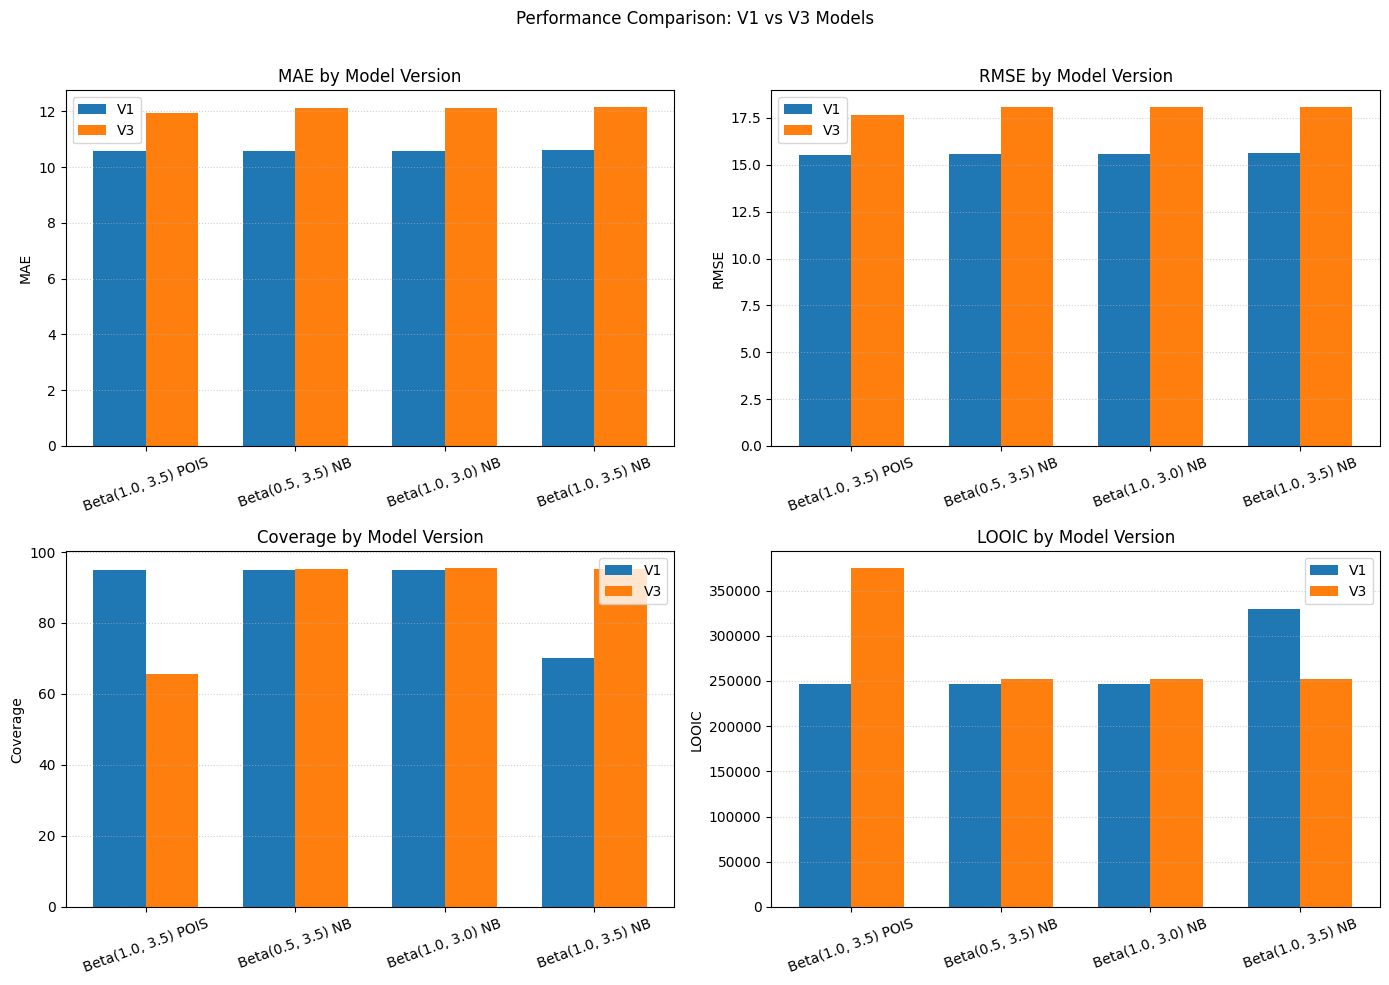

In [48]:
# Comparing all performance metrics between V1 and V3
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    ("MAE", "V1 MAE", "V3 MAE"),
    ("RMSE", "V1 RMSE", "V3 RMSE"),
    ("Coverage", "V1 Coverage", "V3 Coverage"),
    ("LOOIC", "V1 LOOIC", "V3 LOOIC"),
]

n_metrics = len(metrics)
n_models = len(comparison_table)

x = np.arange(n_models)
width = 0.35  # Width of the bars

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for idx, (metric_label, v1_col, v3_col) in enumerate(metrics):
    ax = axs[idx]
    rects1 = ax.bar(x - width/2, comparison_table[v1_col], width, label='V1')
    rects2 = ax.bar(x + width/2, comparison_table[v3_col], width, label='V3')

    ax.set_ylabel(metric_label)
    ax.set_title(f'{metric_label} by Model Version')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_table['Model'], rotation=20)
    ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.6)

fig.suptitle('Performance Comparison: V1 vs V3 Models')
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save plot
plt.savefig(FIG_DIR / "bayesian_models_performance_comparison_v1_v3.png", dpi=300)

plt.show()

**Final Results:**
1. V3 models are uniformly worse at all point predictions. MAE went up by about ~1.5 requests and RMSE by ~2.5.
2. LOO-IC is penalizing all V3 models heavily for the extra interaction terms (251,650 V3's LOO-IC vs. V1's ~246,340)
3. However, coverage did not really change. Across all the Binomial models, coverage stayed ~95%, so it's not like the model made crazy predictions. The additional terms seem to have just introduced more noise.
4. Poisson models are universally still worse (as we expected)
5. 

**Interesting Finding:**
The interesting finding is Beta(1.0, 3.5) Negative Binomial. Its V1 coverage was only 70% but V3 fixed it to 95%. The prior combination could have been improperly set in V1, and the interaction structure happened to fix it. But still doesn't change the overall conclusion.

**Best Model:** The best model across the Bayesian training is the `NegativeBinom(1.0, 3.0)` from Version 1 of training.